# Q3: Learning Agent (Drone) – Rain Prediction for Parcel Delivery

## Training data

| # | Wind | Humidity | Rain |
|---|------|----------|------|
| 1 | Weak | High | Yes |
| 2 | Strong | High | Yes |
| 3 | Weak | Low | No |
| 4 | Weak | Low | Yes |
| 5 | Strong | Low | No |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import entropy
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif

df = pd.DataFrame({
    "Wind":     ["Weak", "Strong", "Weak", "Weak", "Strong"],
    "Humidity": ["High", "High",   "Low",  "Low",  "Low"],
    "Rain":     ["Yes",  "Yes",    "No",   "Yes",  "No"],
})
df.index = range(1, 6)

X = np.column_stack([(df.Wind == "Strong").astype(int), (df.Humidity == "High").astype(int)])
y = (df.Rain == "Yes").astype(int).values

combos = pd.DataFrame([(w, h) for w in ["Weak", "Strong"] for h in ["High", "Low"]], columns=["Wind", "Humidity"])
X_new = np.column_stack([(combos.Wind == "Strong").astype(int), (combos.Humidity == "High").astype(int)])

def drone_action(pred): 
    return ["Hold" if p == 1 else "Deliver" for p in pred]

df

,Wind,Humidity,Rain
1,Weak,High,Yes
2,Strong,High,Yes
3,Weak,Low,No
4,Weak,Low,Yes
5,Strong,Low,No


---
# Part 1: Naive Bayes with Laplace smoothing

For a new day with features $x = (\text{Wind}, \text{Humidity})$:

$$P(\text{Rain}=c \mid x) \;\propto\; P(c)\; P(\text{Wind}\mid c)\; P(\text{Humidity}\mid c)$$

(this uses the naive assumption that features are independent given the class).

**Laplace smoothing** (with $\alpha = 1$, $k$ = number of values of the feature; here $k=2$ for both features):

$$P(x_i = v \mid c) = \frac{\text{count}(x_i=v, c) + \alpha}{\text{count}(c) + \alpha k}$$

In [2]:
nb = CategoricalNB(alpha=1.0).fit(X, y)   

p_no, p_yes = np.exp(nb.class_log_prior_)
print(f"Priors: P(No) = {p_no:.2f}, P(Yes) = {p_yes:.2f}\n")

lik = pd.DataFrame({
    "P(Weak | class)":   np.exp(nb.feature_log_prob_[0])[:, 0],
    "P(Strong | class)": np.exp(nb.feature_log_prob_[0])[:, 1],
    "P(Low | class)":    np.exp(nb.feature_log_prob_[1])[:, 0],
    "P(High | class)":   np.exp(nb.feature_log_prob_[1])[:, 1],
}, index=["No", "Yes"]).round(4)
print(lik, "\n")

score = np.exp(nb.predict_joint_log_proba(X_new))
proba = nb.predict_proba(X_new)
pred = nb.predict(X_new)

nb_df = combos.assign(**{"Yes score": score[:, 1].round(4), "No score": score[:, 0].round(4),
                         "P(Yes)": proba[:, 1].round(3), "P(No)": proba[:, 0].round(3),
                         "Rain pred.": np.where(pred == 1, "Yes", "No"),
                         "Drone action": drone_action(pred)})
nb_df

Priors: P(No) = 0.40, P(Yes) = 0.60

     P(Weak | class)  P(Strong | class)  P(Low | class)  P(High | class)
No               0.5                0.5            0.75             0.25
Yes              0.6                0.4            0.40             0.60 



,Wind,Humidity,Yes score,No score,P(Yes),P(No),Rain pred.,Drone action
0,Weak,High,0.216,0.05,0.812,0.188,Yes,Hold
1,Weak,Low,0.144,0.15,0.490,0.510,No,Deliver
2,Strong,High,0.144,0.05,0.742,0.258,Yes,Hold
3,Strong,Low,0.096,0.15,0.390,0.610,No,Deliver


---
# Part 2: Entropy and Information Gain (Decision Tree, ID3)

$$H(S) = -\sum_c p_c \log_2 p_c \qquad IG(S, A) = H(S) - \sum_v \frac{|S_v|}{|S|} H(S_v)$$

Entropy is computed with `scipy.stats.entropy`. The information gain of a feature equals its mutual information with the label, computed with scikit-learn's `mutual_info_classif` (it returns nats, so we divide by ln 2 to get bits).

In [3]:
H_S = entropy(np.bincount(y), base=2)             
print(f"Entropy H(S) = {H_S:.4f}\n")

ig = mutual_info_classif(X, y, discrete_features=True, random_state=0) / np.log(2)
ig_df = pd.DataFrame({"Information gain": ig.round(4)}, index=["Wind", "Humidity"])
print(ig_df)
print(f"\nRoot node = {ig_df['Information gain'].idxmax()}")

Entropy H(S) = 0.9710

          Information gain
Wind                  0.02
Humidity              0.42

Root node = Humidity


### Resulting tree
- **Humidity = High** → both rows are Yes → **leaf: Rain = Yes**
- **Humidity = Low** → rows 3, 4, 5 (1 Yes, 2 No), so it splits further on Wind, the only attribute left:
  - Wind = Strong → row 5 only → **No**
  - Wind = Weak → rows 3, 4 → 1 Yes, 1 No → an exact tie. The data cannot separate them, and scikit-learn resolves the tie to **No**.

|--- Humidity_High <= 0.50
|   |--- Wind_Strong <= 0.50
|   |   |--- class: 0
|   |--- Wind_Strong >  0.50
|   |   |--- class: 0
|--- Humidity_High >  0.50
|   |--- class: 1



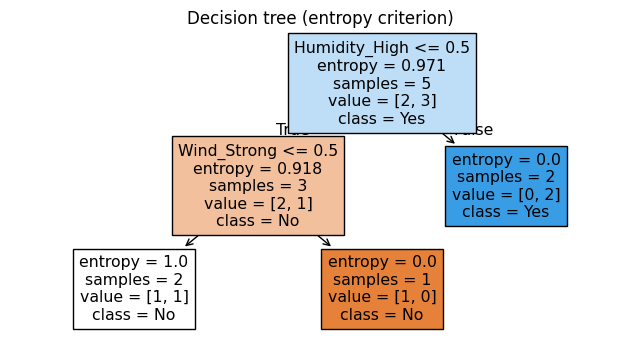

In [4]:
dt = DecisionTreeClassifier(criterion="entropy", random_state=0).fit(X, y)
feature_names = ["Wind_Strong", "Humidity_High"]
print(export_text(dt, feature_names=feature_names))

plt.figure(figsize=(8, 4))
plot_tree(dt, feature_names=feature_names, class_names=["No", "Yes"], filled=True)
plt.title("Decision tree (entropy criterion)")
plt.show()

In [5]:
pred = dt.predict(X_new)
pd.DataFrame({"Wind": combos.Wind, "Humidity": combos.Humidity,
              "P(Yes)": dt.predict_proba(X_new)[:, 1].round(3),
              "Rain pred.": np.where(pred == 1, "Yes", "No"),
              "Drone action": drone_action(pred)})

,Wind,Humidity,P(Yes),Rain pred.,Drone action
0,Weak,High,1.0,Yes,Hold
1,Weak,Low,0.5,No,Deliver
2,Strong,High,1.0,Yes,Hold
3,Strong,Low,0.0,No,Deliver


---
# Part 3: Logistic Regression

Encode: Wind (Strong = 1, Weak = 0), Humidity (High = 1, Low = 0), Rain (Yes = 1, No = 0).

$$P(\text{Rain}=1\mid x) = \sigma(z) = \frac{1}{1+e^{-z}}, \quad z = b + w_1\,\text{Wind} + w_2\,\text{Humidity}$$

**Loss (log-loss):** $J = -\frac1N\sum [y\log \hat p + (1-y)\log(1-\hat p)]$

In [6]:
lr = LogisticRegression(C=10).fit(X, y)
print(f"b (intercept)      = {lr.intercept_[0]:.4f}")
print(f"w_wind (Strong=1)  = {lr.coef_[0][0]:.4f}")
print(f"w_humidity (High=1) = {lr.coef_[0][1]:.4f}")

b (intercept)      = -0.0371
w_wind (Strong=1)  = -0.9511
w_humidity (High=1) = 2.5277


In [7]:
pred = lr.predict(X_new)
lr_df = pd.DataFrame({"Wind": combos.Wind, "Humidity": combos.Humidity,
                      "z": lr.decision_function(X_new).round(3),
                      "P(Yes)": lr.predict_proba(X_new)[:, 1].round(3),
                      "Rain pred.": np.where(pred == 1, "Yes", "No"),
                      "Drone action": drone_action(pred)})
lr_df

,Wind,Humidity,z,P(Yes),Rain pred.,Drone action
0,Weak,High,2.491,0.923,Yes,Hold
1,Weak,Low,-0.037,0.491,No,Deliver
2,Strong,High,1.540,0.823,Yes,Hold
3,Strong,Low,-0.988,0.271,No,Deliver


---
# Part 4: Comparison of the algorithms

In [8]:
models = {"Naive Bayes": nb, "Decision Tree": dt, "Logistic Regression": lr}

comp = combos.copy()
for name, m in models.items():
    comp[f"{name} P(Yes)"] = m.predict_proba(X_new)[:, 1].round(3)
    comp[f"{name} action"] = drone_action(m.predict(X_new))
print(comp.to_string(index=False))

print()
print("Training accuracy -> " + " | ".join(f"{n}: {m.score(X, y):.0%}" for n, m in models.items()))

  Wind Humidity  Naive Bayes P(Yes) Naive Bayes action  Decision Tree P(Yes) Decision Tree action  Logistic Regression P(Yes) Logistic Regression action
  Weak     High               0.812               Hold                   1.0                 Hold                       0.923                       Hold
  Weak      Low               0.490            Deliver                   0.5              Deliver                       0.491                    Deliver
Strong     High               0.742               Hold                   1.0                 Hold                       0.823                       Hold
Strong      Low               0.390            Deliver                   0.0              Deliver                       0.271                    Deliver

Training accuracy -> Naive Bayes: 80% | Decision Tree: 80% | Logistic Regression: 80%
